In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv("cleaned_superstore.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,profit,shipping_cost,order_priority,year,month,month_name,day,day_name,quarter,delivery_days
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,106.140,35.46,Medium,2011,1,January,1,Saturday,1,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,36.036,9.72,Medium,2011,1,January,1,Saturday,1,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,29.640,8.17,High,2011,1,January,1,Saturday,1,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,-26.055,4.82,High,2011,1,January,1,Saturday,1,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,37.770,4.70,Medium,2011,1,January,1,Saturday,1,7


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 51290
Columns : 27
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profi

In [ ]:
df.describe()

,quantity,discount,profit,shipping_cost,year,month,day,quarter,delivery_days
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208,7.522636,15.782960,2.793235,3.969370
std,2.278766,0.212280,174.424113,57.296804,1.098931,3.300056,8.742164,1.066015,1.729437
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000,5.000000,8.000000,2.000000,3.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000,8.000000,16.000000,3.000000,4.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000,10.000000,23.000000,4.000000,5.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000,12.000000,31.000000,4.000000,7.000000


In [ ]:
import pandas as pd

# KPI Sales Analysis

# Convert 'sales' column to numeric, handling potential errors by coercing to NaN
df["sales"] = pd.to_numeric(df["sales"], errors='coerce')

# Drop rows where 'sales' became NaN after conversion
df.dropna(subset=['sales'], inplace=True)

total_sales = df["sales"].sum()

print(f"Total Sales : ${total_sales:,.2f}")

Total Sales : $7,835,128.00


In [ ]:
total_profit = df["profit"].sum()

print(f"Total Profit : ${total_profit:,.2f}")

Total Profit : $714,730.17


In [ ]:
total_orders = df["order_id"].nunique()

print("Total Orders :", total_orders)

Total Orders : 24386


In [ ]:
total_customers = df["customer_name"].nunique()

print("Total Customers :", total_customers)

Total Customers : 795


In [ ]:
average_order = df["sales"].mean()

print(f"Average Order Value : ${average_order:.2f}")

Average Order Value : $161.02


In [ ]:
# Sales Analysis

top_products = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,sales
product_name,
"Eldon File Cart, Single Width",31319.0
"Rogers File Cart, Single Width",22645.0
"Tenex File Cart, Single Width",20778.0
"Smead File Cart, Single Width",20775.0
"Office Star Executive Leather Armchair, Adjustable",19355.0
"Fellowes Lockers, Industrial",19172.0
"Smead Lockers, Industrial",18648.0
"Hewlett Copy Machine, Color",16849.0
"Rogers Lockers, Blue",16494.0


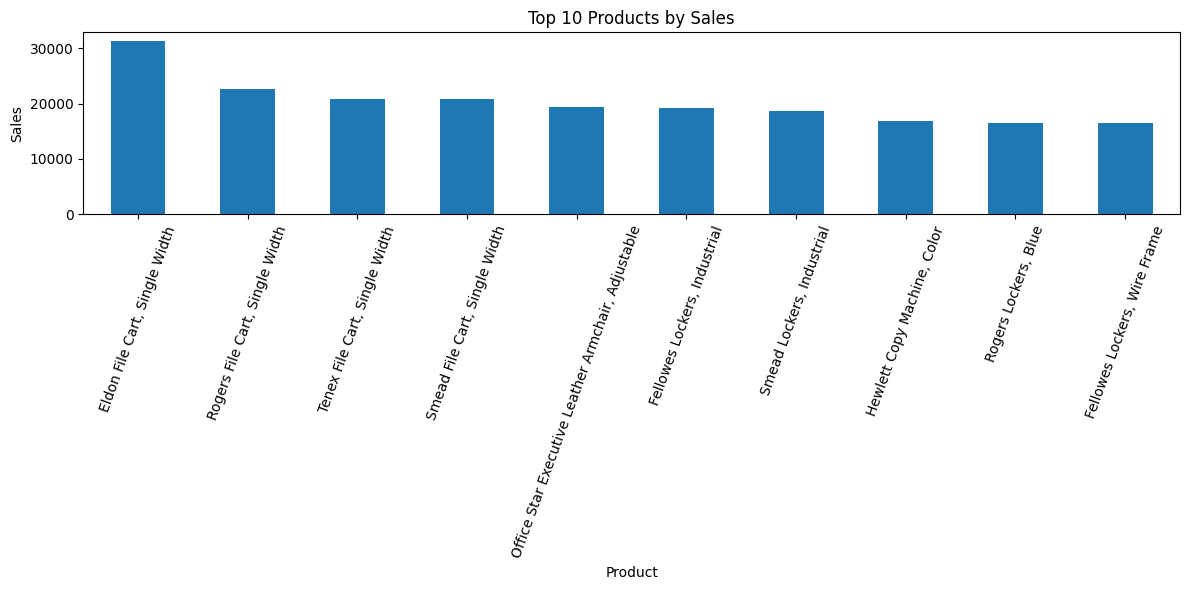

In [ ]:
# Plot top products

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")

plt.xlabel("Product")

plt.ylabel("Sales")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

In [ ]:
# Category Analysis

category_sales = df.groupby("category")["sales"].sum()

category_sales

,sales
category,
Furniture,2406605.0
Office Supplies,2790258.0
Technology,2638265.0


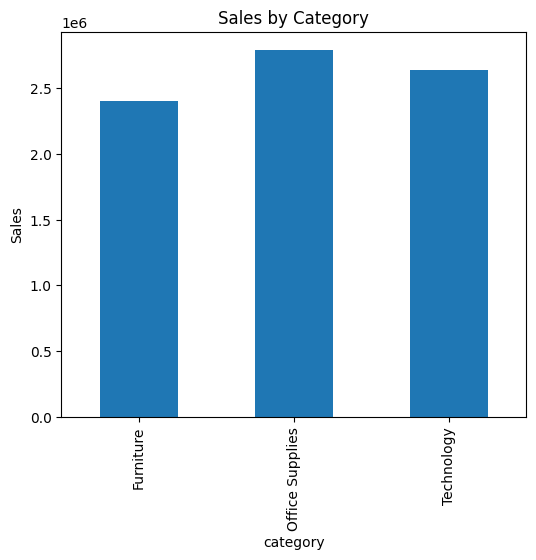

In [ ]:
plt.figure(figsize=(6,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")

plt.ylabel("Sales")

plt.show()

In [ ]:
# Profit Analysis

category_profit = df.groupby("category")["profit"].sum()

category_profit

,profit
category,
Furniture,97049.37790
Office Supplies,350107.32450
Technology,267573.47238


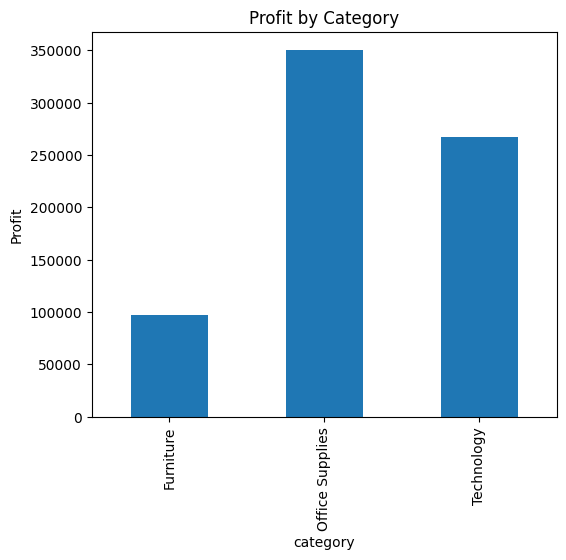

In [ ]:
plt.figure(figsize=(6,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")

plt.ylabel("Profit")

plt.show()

In [ ]:
# Regional Analysis

region_sales = df.groupby("region")["sales"].sum()

region_sales

,sales
region,
Africa,538115.0
Canada,50314.0
Caribbean,251441.0
Central,1806638.0
Central Asia,389506.0
EMEA,575562.0
East,366492.0
North,790546.0
North Asia,453686.0


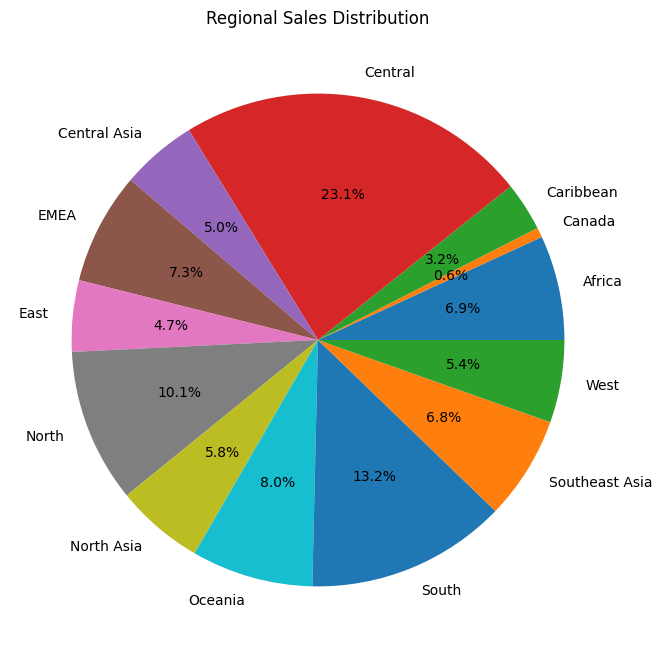

In [ ]:
plt.figure(figsize=(8,8))

region_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Regional Sales Distribution")

plt.show()

In [ ]:
# Market Analysis

market_sales = df.groupby("market")["sales"].sum()

market_sales

,sales
market,
APAC,2000746.0
Africa,538115.0
Canada,50314.0
EMEA,575562.0
EU,1803099.0
LATAM,1563126.0
US,1304166.0


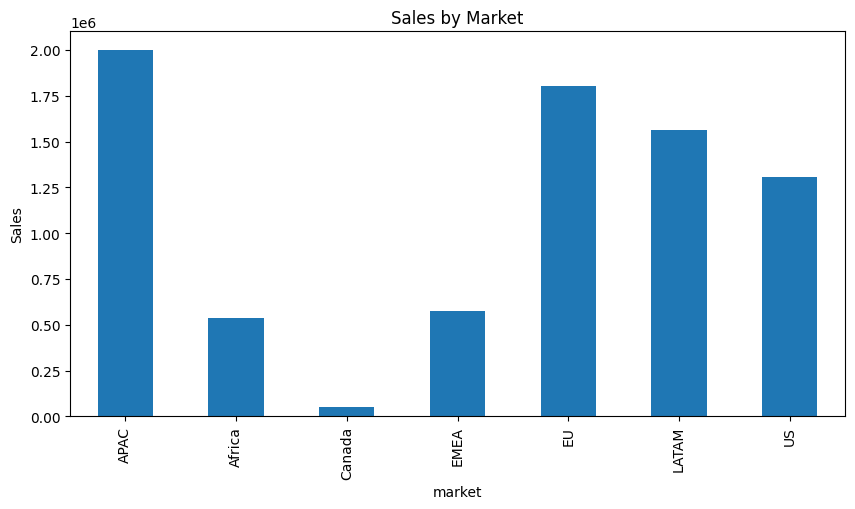

In [ ]:
plt.figure(figsize=(10,5))

market_sales.plot(kind="bar")

plt.title("Sales by Market")

plt.ylabel("Sales")

plt.show()

In [ ]:
# Customer Segment Analysis

segment_sales = df.groupby("segment")["sales"].sum()

segment_sales

,sales
segment,
Consumer,4058118.0
Corporate,2369261.0
Home Office,1407749.0


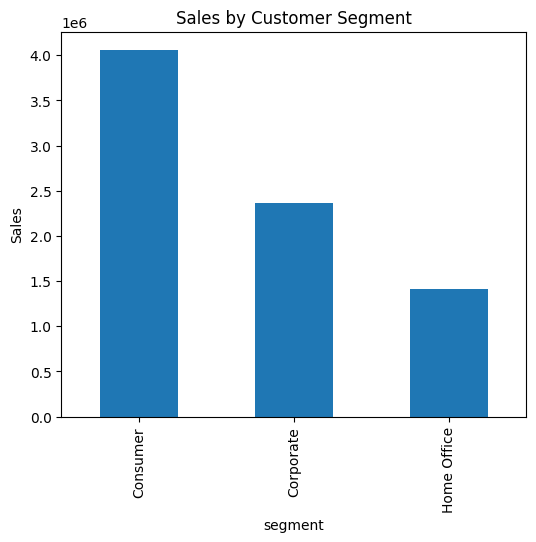

In [ ]:
plt.figure(figsize=(6,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")

plt.ylabel("Sales")

plt.show()

In [ ]:
# Monthly Sales Trend

monthly_sales = df.groupby("month_name")["sales"].sum()

monthly_sales

,sales
month_name,
April,455594.0
August,784982.0
December,957117.0
February,339990.0
January,385781.0
July,488345.0
June,807184.0
March,466475.0
May,562178.0


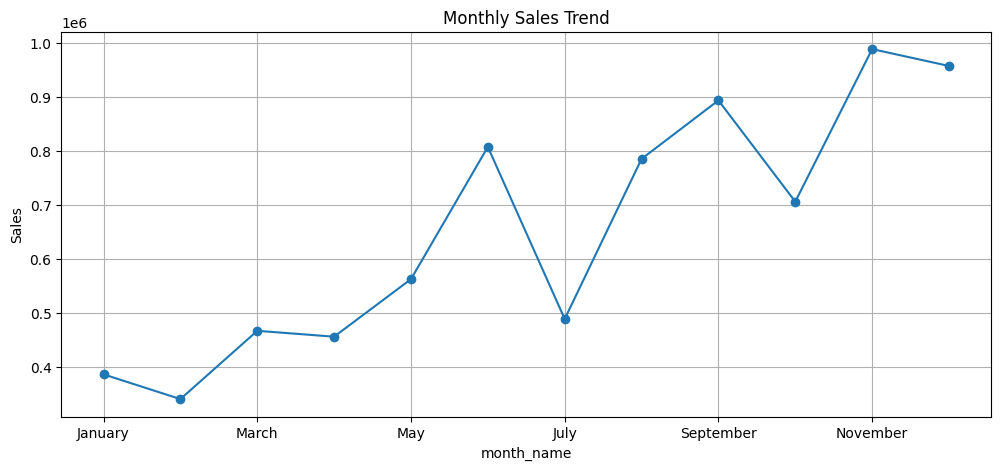

In [ ]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [ ]:
# Top States

top_states = df.groupby("state")["sales"].sum().nlargest(10)

top_states

,sales
state,
England,273710.0
California,270615.0
Ile-de-France,188108.0
New York,153366.0
New South Wales,145380.0
North Rhine-Westphalia,135097.0
Queensland,125019.0
Texas,118835.0
San Salvador,105245.0


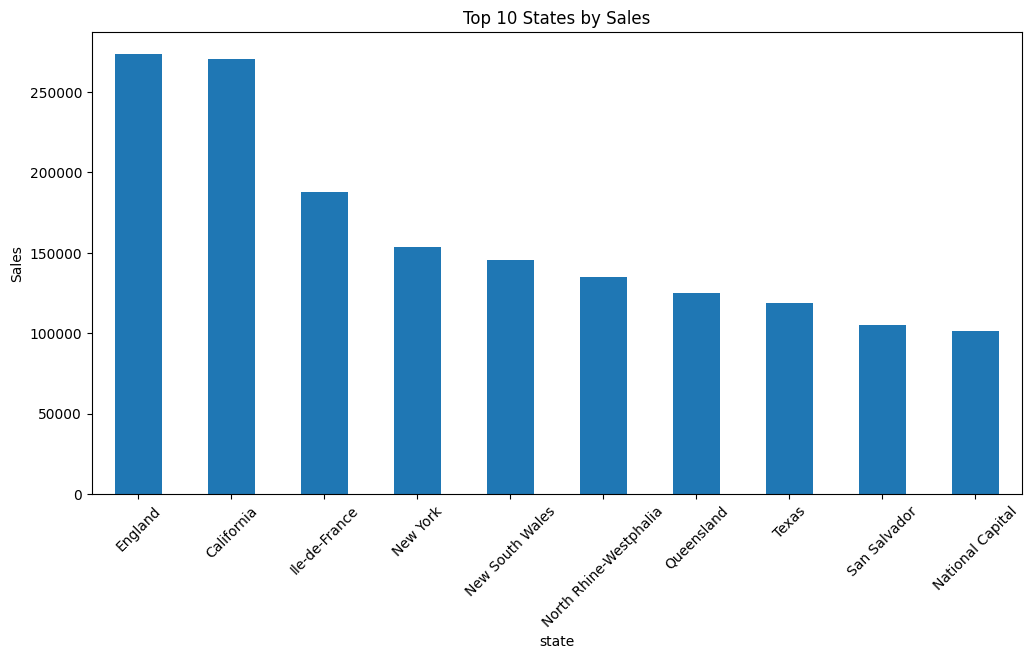

In [ ]:
plt.figure(figsize=(12,6))

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Shipping Mode Analysis

shipping = df.groupby("ship_mode")["sales"].sum()

shipping

,sales
ship_mode,
First Class,1133651.0
Same Day,398788.0
Second Class,1583086.0
Standard Class,4719603.0


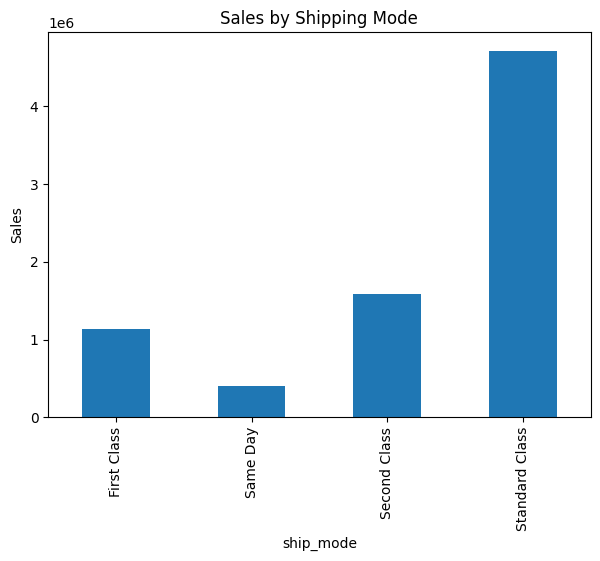

In [ ]:
plt.figure(figsize=(7,5))

shipping.plot(kind="bar")

plt.title("Sales by Shipping Mode")

plt.ylabel("Sales")

plt.show()

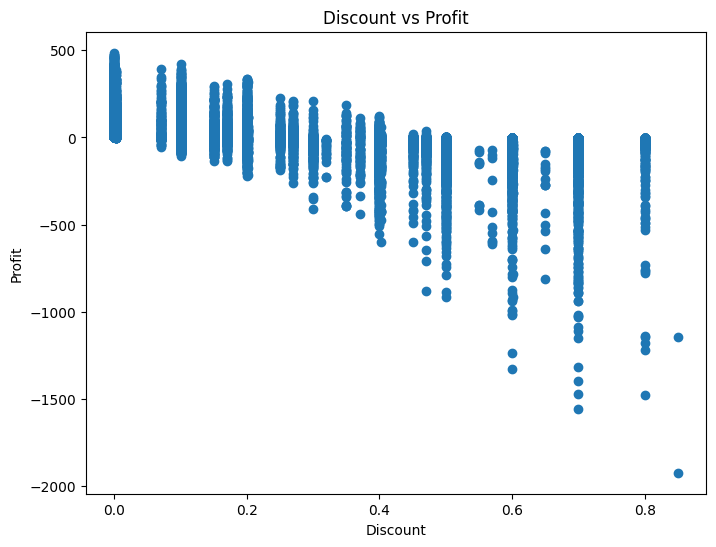

In [ ]:
# Discount vs Profit

plt.figure(figsize=(8,6))

plt.scatter(
    df["discount"],
    df["profit"]
)

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.title("Discount vs Profit")

plt.show()

In [ ]:
# Summary Table

summary = pd.DataFrame({

"Metric":[
"Total Sales",
"Total Profit",
"Orders",
"Customers",
"Average Order Value"
],

"Value":[
total_sales,
total_profit,
total_orders,
total_customers,
average_order
]

})

summary

,Metric,Value
0,Total Sales,7.835128e+06
1,Total Profit,7.147302e+05
2,Orders,2.438600e+04
3,Customers,7.950000e+02
4,Average Order Value,1.610178e+02


In [ ]:
summary.to_csv("business_summary.csv", index=False)

print("Business summary saved successfully.")

Business summary saved successfully.
